# Figure 3 Reproduction Notebook

Goal: reproduce Figure 3 data logic and generate model-minus-climatology heatmaps.

Author-provided data policy:
- IFS: use 2019-2023 (no 2024)
- FuXi-S2S: use 2019-2021 (later years unavailable)
- NGCM: use data under the `climatology` folder
- Resolution: 4-degree only

Window setup:
- Forecast windows: 1-5, 6-10, 11-15, 16-20, 21-25, 26-30
- Tolerances: +/-2, +/-2, +/-3, +/-3, +/-5, +/-5 days
- Delta = Model - Climatology (negative is better)


## Step 1: Imports
Import dependencies and MonsoonBench modules used below.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import BoundaryNorm

from monsoonbench.metrics.base import OnsetMetricsBase
from monsoonbench.metrics.climatology import ClimatologyOnsetMetrics
from monsoonbench.metrics.deterministic import DeterministicOnsetMetrics
from monsoonbench.metrics.probabilistic import ProbabilisticOnsetMetrics
from monsoonbench.spatial.regions import get_cmz_polygon_coords, points_inside_polygon

## Step 2: Global Settings
Define figure-wide fixed settings in one place.


In [2]:
WINDOW_BINS = [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
WINDOW_TOLERANCE = [2, 2, 3, 3, 5, 5]

# Important: use legacy CMZ polygon from original metrics scripts for 4-degree runs
USE_LEGACY_CMZ_POLYGON = True

# Author-aligned Fig.3 settings (non-cumulative bins)
# 1) 5-day bins are evaluated independently
FIG3_OBS_WINDOW_MODE = "bin"  # TP/FP prediction window: [start_day, end_day]
# 2) Predictions outside the current bin are treated as out-of-window for this bin
FIG3_CLASSIFICATION_MODE = "strict_window"
# 3) FN/TN and MR denominator both use the same non-cumulative bin window
FIG3_FN_TN_OBS_MODE = "bin"
FIG3_MR_DENOM_MODE = "obs_in_bin"  # MR = FN / N(obs lead in [start_day, end_day])
# 4) Spatial and temporal aggregation order
FIG3_AGGREGATE_MODE = "gridmean"
FIG3_TEMPORAL_AGG_MODE = "year_then_average"

print("WINDOW_BINS =", WINDOW_BINS)
print("WINDOW_TOLERANCE =", WINDOW_TOLERANCE)
print("USE_LEGACY_CMZ_POLYGON =", USE_LEGACY_CMZ_POLYGON)
print("FIG3_OBS_WINDOW_MODE =", FIG3_OBS_WINDOW_MODE)
print("FIG3_CLASSIFICATION_MODE =", FIG3_CLASSIFICATION_MODE)
print("FIG3_FN_TN_OBS_MODE =", FIG3_FN_TN_OBS_MODE)
print("FIG3_MR_DENOM_MODE =", FIG3_MR_DENOM_MODE)
print("FIG3_AGGREGATE_MODE =", FIG3_AGGREGATE_MODE)
print("FIG3_TEMPORAL_AGG_MODE =", FIG3_TEMPORAL_AGG_MODE)

WINDOW_BINS = [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
WINDOW_TOLERANCE = [2, 2, 3, 3, 5, 5]
USE_LEGACY_CMZ_POLYGON = True
FIG3_OBS_WINDOW_MODE = bin
FIG3_CLASSIFICATION_MODE = strict_window
FIG3_FN_TN_OBS_MODE = bin
FIG3_MR_DENOM_MODE = obs_in_bin
FIG3_AGGREGATE_MODE = gridmean
FIG3_TEMPORAL_AGG_MODE = year_then_average


## Step 3: Metric Helper (Single Window)
Compute CMZ-mean MAE/FAR/MR for one forecast window and one tolerance.


In [3]:
def _score_window_core(
    onset_df: pd.DataFrame,
    start_day: int,
    end_day: int,
    tolerance_days: int,
    obs_window_mode: str = "bin",
    classification_mode: str = "strict_window",
    fn_tn_obs_mode: str = "bin",
    mr_denom_mode: str = "obs_in_bin",
) -> dict[str, float]:
    """Score one window on one table and return pooled contingency counts + metrics."""
    if onset_df.empty:
        return {
            "mae": np.nan,
            "far": np.nan,
            "mr": np.nan,
            "tp": 0,
            "fp": 0,
            "fn": 0,
            "tn": 0,
            "n_rows": 0,
            "n_obs_in": 0,
            "n_obs_in_bin": 0,
            "n_obs_in_cumulative_to_end": 0,
            "n_ignored": 0,
        }

    onset_table = onset_df.copy()
    onset_table["init_dt"] = pd.to_datetime(onset_table["init_time"], errors="coerce")
    onset_table["obs_dt"] = pd.to_datetime(
        onset_table["obs_onset_date"], errors="coerce"
    )
    onset_table["pred_dt"] = pd.to_datetime(onset_table["onset_date"], errors="coerce")
    onset_table = onset_table.dropna(subset=["init_dt", "obs_dt"])

    onset_table["obs_lead"] = (onset_table["obs_dt"] - onset_table["init_dt"]).dt.days
    onset_table["pred_lead"] = (onset_table["pred_dt"] - onset_table["init_dt"]).dt.days

    onset_table["obs_in_bin"] = onset_table["obs_lead"].between(
        start_day, end_day, inclusive="both"
    )
    onset_table["obs_in_cumulative_to_end"] = onset_table["obs_lead"].between(
        1, end_day, inclusive="both"
    )

    if obs_window_mode == "bin":
        obs_for_pred = "obs_in_bin"
        pred_in_series = pd.notna(onset_table["pred_dt"]) & onset_table[
            "pred_lead"
        ].between(start_day, end_day, inclusive="both")
    elif obs_window_mode == "cumulative":
        obs_for_pred = "obs_in_cumulative_to_end"
        pred_in_series = pd.notna(onset_table["pred_dt"]) & onset_table[
            "pred_lead"
        ].between(1, end_day, inclusive="both")
    else:
        raise ValueError(f"Unsupported obs_window_mode: {obs_window_mode}")

    if fn_tn_obs_mode not in ("bin", "cumulative_to_end"):
        raise ValueError(f"Unsupported fn_tn_obs_mode: {fn_tn_obs_mode}")
    obs_for_no_pred = (
        "obs_in_bin" if fn_tn_obs_mode == "bin" else "obs_in_cumulative_to_end"
    )

    tp = 0
    fp = 0
    fn = 0
    tn = 0
    abs_errors = []

    for idx, row in onset_table.iterrows():
        has_pred = pd.notna(row["pred_dt"])
        pred_in = bool(pred_in_series.loc[idx])

        if pred_in:
            abs_err = abs((row["pred_dt"] - row["obs_dt"]).days)
            if abs_err <= tolerance_days:
                tp += 1
            else:
                fp += 1
            abs_errors.append(abs_err)
        else:
            if classification_mode == "strict_window":
                if bool(row[obs_for_pred]):
                    fn += 1
                else:
                    tn += 1
            elif classification_mode == "legacy_skip_pred_out":
                if not has_pred:
                    if bool(row[obs_for_no_pred]):
                        fn += 1
                    else:
                        tn += 1
            elif classification_mode == "legacy_plus_tn_noobs":
                if not has_pred:
                    if bool(row[obs_for_no_pred]):
                        fn += 1
                    else:
                        tn += 1
                else:
                    if not bool(row[obs_for_no_pred]):
                        tn += 1
            else:
                raise ValueError(
                    f"Unsupported classification_mode: {classification_mode}"
                )

    mae = float(np.mean(abs_errors)) if len(abs_errors) > 0 else np.nan
    far = float(fp / (fp + tn) * 100.0) if (fp + tn) > 0 else np.nan

    n_obs_in_bin = int(onset_table["obs_in_bin"].sum())
    n_obs_in_cumulative = int(onset_table["obs_in_cumulative_to_end"].sum())

    if mr_denom_mode == "obs_in_bin":
        mr_denom = n_obs_in_bin
    elif mr_denom_mode == "obs_in_cumulative_to_end":
        mr_denom = n_obs_in_cumulative
    elif mr_denom_mode == "tp_fn":
        mr_denom = tp + fn
    else:
        raise ValueError(f"Unsupported mr_denom_mode: {mr_denom_mode}")

    mr = float(fn / mr_denom * 100.0) if mr_denom > 0 else np.nan

    return {
        "mae": mae,
        "far": far,
        "mr": mr,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "n_rows": int(len(onset_table)),
        "n_obs_in": int(onset_table[obs_for_pred].sum()),
        "n_obs_in_bin": n_obs_in_bin,
        "n_obs_in_cumulative_to_end": n_obs_in_cumulative,
        "n_ignored": int(len(onset_table) - (tp + fp + fn + tn)),
    }


def window_metrics_cmz(
    onset_df: pd.DataFrame,
    start_day: int,
    end_day: int,
    tolerance_days: int,
    obs_window_mode: str = FIG3_OBS_WINDOW_MODE,
    classification_mode: str = FIG3_CLASSIFICATION_MODE,
    fn_tn_obs_mode: str = FIG3_FN_TN_OBS_MODE,
    mr_denom_mode: str = FIG3_MR_DENOM_MODE,
    aggregate_mode: str = FIG3_AGGREGATE_MODE,
) -> dict[str, float]:
    """Compute CMZ metrics for one forecast window.

    Returns pooled TP/FP/FN/TN for bookkeeping, and metric values according to `aggregate_mode`.
    """
    pooled = _score_window_core(
        onset_df,
        start_day,
        end_day,
        tolerance_days,
        obs_window_mode=obs_window_mode,
        classification_mode=classification_mode,
        fn_tn_obs_mode=fn_tn_obs_mode,
        mr_denom_mode=mr_denom_mode,
    )

    if aggregate_mode == "pooled":
        return pooled

    if aggregate_mode != "gridmean":
        raise ValueError(f"Unsupported aggregate_mode: {aggregate_mode}")

    if onset_df.empty:
        pooled["n_grids"] = 0
        return pooled

    per_grid = []
    for (_, _), g in onset_df.groupby(["lat", "lon"], dropna=False):
        gm = _score_window_core(
            g,
            start_day,
            end_day,
            tolerance_days,
            obs_window_mode=obs_window_mode,
            classification_mode=classification_mode,
            fn_tn_obs_mode=fn_tn_obs_mode,
            mr_denom_mode=mr_denom_mode,
        )
        per_grid.append(gm)

    gdf = pd.DataFrame(per_grid)
    pooled["mae"] = float(gdf["mae"].mean(skipna=True))
    pooled["far"] = float(gdf["far"].mean(skipna=True))
    pooled["mr"] = float(gdf["mr"].mean(skipna=True))
    pooled["n_grids"] = int(len(gdf))
    return pooled

## Step 4: Core Compute Function (One Model)
Pipeline: load data -> CMZ slice -> model + climatology onset -> per-window metrics -> delta table.


In [4]:
def compute_fig3_delta_table(args: dict) -> pd.DataFrame:
    """Compute Figure-3 style model-minus-climatology delta metrics table."""
    years = args["years"]
    model_type = args.get("model_type", "probabilistic")
    mok = args.get("mok", True)
    max_forecast_day = args.get("max_forecast_day", 30)
    date_filter_year = args.get("date_filter_year", 2024)
    file_pattern = args.get("file_pattern", "{}.nc")
    temporal_agg_mode = args.get("temporal_agg_mode", FIG3_TEMPORAL_AGG_MODE)

    pr = ProbabilisticOnsetMetrics()
    det = DeterministicOnsetMetrics()
    cl = ClimatologyOnsetMetrics()

    thres_da = xr.open_dataset(args["thres_file"])["MWmean"]

    # CMZ mask from threshold grid
    lat_vals = thres_da.lat.values
    lon_vals = thres_da.lon.values
    resolution = float(abs(lat_vals[1] - lat_vals[0]))

    if USE_LEGACY_CMZ_POLYGON:
        if abs(resolution - 4.0) < 0.1:
            poly_lon = np.array([86, 74, 74, 70, 70, 82, 82, 86, 86])
            poly_lat = np.array([18, 18, 22, 22, 30, 30, 26, 26, 18])
        elif abs(resolution - 2.0) < 0.1:
            poly_lon = np.array(
                [83, 75, 75, 71, 71, 77, 77, 79, 79, 83, 83, 89, 89, 85, 85, 83, 83]
            )
            poly_lat = np.array(
                [17, 17, 21, 21, 29, 29, 27, 27, 25, 25, 23, 23, 21, 21, 19, 19, 17]
            )
        elif abs(resolution - 1.0) < 0.1:
            poly_lon = np.array(
                [
                    74,
                    85,
                    85,
                    86,
                    86,
                    87,
                    87,
                    88,
                    88,
                    88,
                    85,
                    85,
                    82,
                    82,
                    79,
                    79,
                    78,
                    78,
                    69,
                    69,
                    74,
                    74,
                ]
            )
            poly_lat = np.array(
                [
                    18,
                    18,
                    19,
                    19,
                    20,
                    20,
                    21,
                    21,
                    21,
                    24,
                    24,
                    25,
                    25,
                    26,
                    26,
                    27,
                    27,
                    28,
                    28,
                    21,
                    21,
                    18,
                ]
            )
        else:
            raise ValueError(f"Unsupported legacy CMZ resolution: {resolution}")
    else:
        cmz_coords = get_cmz_polygon_coords(resolution)
        if cmz_coords is None:
            raise ValueError(f"Unsupported CMZ resolution: {resolution}")
        poly_lon, poly_lat = cmz_coords

    _, inside_lons_raw, inside_lats_raw = points_inside_polygon(
        poly_lon, poly_lat, lon_vals, lat_vals
    )
    cmz_pairs = pd.DataFrame(
        {"lat": inside_lats_raw, "lon": inside_lons_raw}
    ).drop_duplicates()
    inside_lons = np.unique(inside_lons_raw)
    inside_lats = np.unique(inside_lats_raw)
    thres_slice = thres_da.sel(lat=inside_lats, lon=inside_lons)

    # Climatology baseline (once)
    clim_onset_doy = cl.compute_climatological_onset(
        args["imd_folder"],
        args["thres_file"],
        mok=mok,
    ).sel(lat=inside_lats, lon=inside_lons)

    model_by_year = {}
    clim_by_year = {}
    processed_years = []
    skipped_years = []

    for year in years:
        forecast_file = Path(args["model_forecast_dir"]) / file_pattern.format(year)
        if not forecast_file.exists():
            print(f"Skipping year {year}: missing forecast file {forecast_file.name}")
            skipped_years.append(year)
            continue

        print(f"Processing year {year} ...")
        try:
            if model_type == "probabilistic":
                p_model, init_times = pr.get_forecast_probabilistic_twice_weekly_2(
                    year,
                    args["model_forecast_dir"],
                    args["mem_num"],
                    date_filter_year=date_filter_year,
                    file_pattern=file_pattern,
                )
                p_model = p_model.sel(lat=inside_lats, lon=inside_lons)
            elif model_type == "deterministic":
                p_model = det.get_forecast_deterministic_twice_weekly(
                    year, args["model_forecast_dir"]
                ).sel(lat=inside_lats, lon=inside_lons)
                init_times = p_model.init_time.values
            else:
                raise ValueError(f"Unsupported model_type: {model_type}")

            rainfall = OnsetMetricsBase.load_imd_rainfall(year, args["imd_folder"]).sel(
                lat=inside_lats, lon=inside_lons
            )
            onset_obs = OnsetMetricsBase.detect_observed_onset(
                rainfall,
                thres_slice,
                year,
                mok=mok,
            )

            if model_type == "probabilistic":
                model_df = pr.compute_mean_onset_for_all_members(
                    p_model,
                    thres_slice,
                    onset_obs,
                    max_forecast_day=max_forecast_day,
                    mok=mok,
                )
            else:
                model_df = det.compute_onset_for_deterministic_model(
                    p_model,
                    thres_slice,
                    onset_obs,
                    max_forecast_day=max_forecast_day,
                    mok=mok,
                )

            model_df = model_df.merge(cmz_pairs, on=["lat", "lon"], how="inner")
            clim_df = cl.compute_climatology_as_forecast(
                clim_onset_doy,
                year,
                pd.to_datetime(init_times),
                onset_obs,
                max_forecast_day=max_forecast_day,
                mok=mok,
            )
            clim_df = clim_df.merge(cmz_pairs, on=["lat", "lon"], how="inner")

            model_by_year[year] = model_df
            clim_by_year[year] = clim_df
            processed_years.append(year)

        except Exception as exc:
            print(f"Skipping year {year}: {exc}")
            skipped_years.append(year)

    if not model_by_year or not clim_by_year:
        raise ValueError(
            "No years were successfully processed. Check file paths, model_type, and year availability."
        )

    print(f"Processed years: {processed_years}")
    if skipped_years:
        print(f"Skipped years: {skipped_years}")

    # Compute window metrics
    rows = []
    for (w_start, w_end), tol in zip(WINDOW_BINS, WINDOW_TOLERANCE):
        if temporal_agg_mode == "year_then_average":
            model_vals = []
            clim_vals = []
            model_counts = []
            clim_counts = []

            for y in processed_years:
                m_y = window_metrics_cmz(
                    model_by_year[y],
                    w_start,
                    w_end,
                    tol,
                    obs_window_mode=FIG3_OBS_WINDOW_MODE,
                    classification_mode=FIG3_CLASSIFICATION_MODE,
                    fn_tn_obs_mode=FIG3_FN_TN_OBS_MODE,
                    mr_denom_mode=FIG3_MR_DENOM_MODE,
                    aggregate_mode=FIG3_AGGREGATE_MODE,
                )
                c_y = window_metrics_cmz(
                    clim_by_year[y],
                    w_start,
                    w_end,
                    tol,
                    obs_window_mode=FIG3_OBS_WINDOW_MODE,
                    classification_mode=FIG3_CLASSIFICATION_MODE,
                    fn_tn_obs_mode=FIG3_FN_TN_OBS_MODE,
                    mr_denom_mode=FIG3_MR_DENOM_MODE,
                    aggregate_mode=FIG3_AGGREGATE_MODE,
                )
                model_vals.append(m_y)
                clim_vals.append(c_y)
                model_counts.append(
                    (
                        m_y["tp"],
                        m_y["fp"],
                        m_y["fn"],
                        m_y["tn"],
                        m_y.get("n_rows", 0),
                        m_y.get("n_ignored", 0),
                    )
                )
                clim_counts.append(
                    (
                        c_y["tp"],
                        c_y["fp"],
                        c_y["fn"],
                        c_y["tn"],
                        c_y.get("n_rows", 0),
                        c_y.get("n_ignored", 0),
                    )
                )

            def _nanmean(items, key):
                vals = [d[key] for d in items if pd.notna(d[key])]
                return float(np.mean(vals)) if vals else np.nan

            m = {
                "mae": _nanmean(model_vals, "mae"),
                "far": _nanmean(model_vals, "far"),
                "mr": _nanmean(model_vals, "mr"),
                "tp": int(sum(x[0] for x in model_counts)),
                "fp": int(sum(x[1] for x in model_counts)),
                "fn": int(sum(x[2] for x in model_counts)),
                "tn": int(sum(x[3] for x in model_counts)),
                "n_rows": int(sum(x[4] for x in model_counts)),
                "n_ignored": int(sum(x[5] for x in model_counts)),
            }
            c = {
                "mae": _nanmean(clim_vals, "mae"),
                "far": _nanmean(clim_vals, "far"),
                "mr": _nanmean(clim_vals, "mr"),
                "tp": int(sum(x[0] for x in clim_counts)),
                "fp": int(sum(x[1] for x in clim_counts)),
                "fn": int(sum(x[2] for x in clim_counts)),
                "tn": int(sum(x[3] for x in clim_counts)),
                "n_rows": int(sum(x[4] for x in clim_counts)),
                "n_ignored": int(sum(x[5] for x in clim_counts)),
            }
        else:
            all_model = pd.concat(
                [model_by_year[y] for y in processed_years], ignore_index=True
            )
            all_clim = pd.concat(
                [clim_by_year[y] for y in processed_years], ignore_index=True
            )
            m = window_metrics_cmz(
                all_model,
                w_start,
                w_end,
                tol,
                obs_window_mode=FIG3_OBS_WINDOW_MODE,
                classification_mode=FIG3_CLASSIFICATION_MODE,
                fn_tn_obs_mode=FIG3_FN_TN_OBS_MODE,
                mr_denom_mode=FIG3_MR_DENOM_MODE,
                aggregate_mode=FIG3_AGGREGATE_MODE,
            )
            c = window_metrics_cmz(
                all_clim,
                w_start,
                w_end,
                tol,
                obs_window_mode=FIG3_OBS_WINDOW_MODE,
                classification_mode=FIG3_CLASSIFICATION_MODE,
                fn_tn_obs_mode=FIG3_FN_TN_OBS_MODE,
                mr_denom_mode=FIG3_MR_DENOM_MODE,
                aggregate_mode=FIG3_AGGREGATE_MODE,
            )

        for metric, label in [
            ("mae", "MAE (days)"),
            ("far", "FAR (%)"),
            ("mr", "MR (%)"),
        ]:
            mv = m[metric]
            cv = c[metric]
            dv = mv - cv if (pd.notna(mv) and pd.notna(cv)) else np.nan
            rows.append(
                {
                    "metric": label,
                    "window": f"{w_start}-{w_end}",
                    "tolerance_days": tol,
                    "model": mv,
                    "climatology": cv,
                    "delta": dv,
                    "model_tp": m["tp"],
                    "model_fp": m["fp"],
                    "model_fn": m["fn"],
                    "model_tn": m["tn"],
                    "clim_tp": c["tp"],
                    "clim_fp": c["fp"],
                    "clim_fn": c["fn"],
                    "clim_tn": c["tn"],
                    "n_rows_model": m["n_rows"],
                    "n_rows_clim": c["n_rows"],
                    "model_n_ignored": int(m.get("n_ignored", 0)),
                    "clim_n_ignored": int(c.get("n_ignored", 0)),
                    "processed_years": ",".join(str(y) for y in processed_years),
                    "date_filter_year": date_filter_year,
                    "obs_window_mode": FIG3_OBS_WINDOW_MODE,
                    "classification_mode": FIG3_CLASSIFICATION_MODE,
                    "fn_tn_obs_mode": FIG3_FN_TN_OBS_MODE,
                    "mr_denom_mode": FIG3_MR_DENOM_MODE,
                    "aggregate_mode": FIG3_AGGREGATE_MODE,
                    "temporal_agg_mode": temporal_agg_mode,
                }
            )

    return pd.DataFrame(rows)

## Step 5: Plot Helper
Render a 3x6 delta heatmap and annotate each cell with numeric values.


In [5]:
def plot_fig3_delta_heatmap(
    delta_df: pd.DataFrame, model_name: str, save_dir: Path | str
) -> Path:
    """Plot single-model delta heatmap (legacy notebook style + discrete levels)."""
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    heatmap_df = delta_df.pivot_table(index="metric", columns="window", values="delta")
    heatmap_df = heatmap_df.loc[
        ["MAE (days)", "FAR (%)", "MR (%)"],
        ["1-5", "6-10", "11-15", "16-20", "21-25", "26-30"],
    ]

    arr = heatmap_df.to_numpy(dtype=float)

    # Discrete bins while preserving previous compact single-panel style
    vmax = np.nanmax(np.abs(arr))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0
    step = max(0.5, round(vmax / 8, 2))
    boundaries = np.arange(-vmax, vmax + step, step)
    norm = BoundaryNorm(boundaries=boundaries, ncolors=plt.cm.RdBu_r.N)

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(
        arr, cmap="RdBu_r", norm=norm, aspect="auto", interpolation="nearest"
    )

    ax.set_xticks(np.arange(arr.shape[1]))
    ax.set_xticklabels(heatmap_df.columns)
    ax.set_yticks(np.arange(arr.shape[0]))
    ax.set_yticklabels(heatmap_df.index)
    ax.set_xlabel("Forecast Window (days)")
    ax.set_title(f"Figure 3-style Delta Metrics vs Climatology | {model_name}")

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            v = arr[i, j]
            txt = "nan" if np.isnan(v) else f"{v:.2f}"
            color = "white" if np.isfinite(v) and abs(v) > 0.55 * vmax else "black"
            ax.text(j, i, txt, ha="center", va="center", color=color, fontsize=10)

    cbar = plt.colorbar(im, ax=ax, shrink=0.92, boundaries=boundaries)
    cbar.set_label("Model - Climatology (negative is better)")

    plt.tight_layout()

    out_path = save_dir / f"fig3_delta_heatmap_{model_name}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    return out_path

## Step 6: Configure One Model (Example: IFS)
Set paths and parameters for one model run. Duplicate this for other models.


In [6]:
repo_root = Path.cwd()
if not (repo_root / "pyproject.toml").exists():
    repo_root = next(
        (p for p in repo_root.parents if (p / "pyproject.toml").exists()), repo_root
    )

data_dir = repo_root / "data"
output_dir = repo_root / "examples" / "demo_notebooks" / "outputs"

args = {
    "model_forecast_dir": f"{data_dir}/model_forecast_data/IFS-S2S/tp_4p0",
    "imd_folder": f"{data_dir}/imd_rainfall_data/4p0",
    "thres_file": f"{data_dir}/imd_onset_threshold/mwset4x4.nc4",
    "mem_num": 11,
    "model_name": "ifs",
    "years": [2019, 2020, 2021, 2022, 2023, 2024],
    "date_filter_year": 2024,
    "file_pattern": "{}.nc",
    "max_forecast_day": 30,
    "save_dir": output_dir,
    "mok": True,
}

args

{'model_forecast_dir': 'c:\\Users\\50573\\Documents\\AAASlashie\\MSCAPP\\2026-WINTER\\DATA 27100\\monsoon-bench\\data/model_forecast_data/IFS-S2S/tp_4p0',
 'imd_folder': 'c:\\Users\\50573\\Documents\\AAASlashie\\MSCAPP\\2026-WINTER\\DATA 27100\\monsoon-bench\\data/imd_rainfall_data/4p0',
 'thres_file': 'c:\\Users\\50573\\Documents\\AAASlashie\\MSCAPP\\2026-WINTER\\DATA 27100\\monsoon-bench\\data/imd_onset_threshold/mwset4x4.nc4',
 'mem_num': 11,
 'model_name': 'ifs',
 'years': [2019, 2020, 2021, 2022, 2023, 2024],
 'date_filter_year': 2024,
 'file_pattern': '{}.nc',
 'max_forecast_day': 30,
 'save_dir': WindowsPath('c:/Users/50573/Documents/AAASlashie/MSCAPP/2026-WINTER/DATA 27100/monsoon-bench/examples/demo_notebooks/outputs'),
 'mok': True}

## Step 6.5: Check Which Models Have 2024 Data
Use this before running Figure 3 to confirm year coverage.

Note: if a model does not include 2024 while the paper uses 2019-2024,
your numeric result will generally differ from the paper for that model.


In [7]:
# Scan model folders and validate model type / ensemble size / year coverage
# This follows the author-provided year policy per model.
PAPER_YEARS_BY_MODEL = {
    "ifs": [2019, 2020, 2021, 2022, 2023],
    "fuxi-s2s": [2019, 2020, 2021],
    "gencast": [2019, 2020, 2021, 2022, 2023, 2024],
    "ngcm": [2019, 2020, 2021, 2022, 2023, 2024],
    "aifs": [2019, 2020, 2021, 2022, 2023, 2024],
    "fuxi": [2019, 2020, 2021, 2022, 2023, 2024],
    "graphcast": [2019, 2020, 2021, 2022, 2023, 2024],
}

model_specs = {
    "ifs": {
        "model_type": "probabilistic",
        "expected_ens": 11,
        "path": data_dir / "model_forecast_data" / "IFS-S2S" / "tp_4p0",
    },
    "aifs": {
        "model_type": "deterministic",
        "expected_ens": None,
        "path": data_dir / "model_forecast_data" / "aifs" / "daily_0z" / "tp_4p0",
    },
    "fuxi": {
        "model_type": "deterministic",
        "expected_ens": None,
        "path": data_dir
        / "model_forecast_data"
        / "fuxi"
        / "output_daily_paper_0z_4p0"
        / "tp_lsm",
    },
    "graphcast": {
        "model_type": "deterministic",
        "expected_ens": None,
        "path": data_dir
        / "model_forecast_data"
        / "graphcast37"
        / "output_twice_weekly_paper_0z_4p0"
        / "tp_lsm",
    },
    "gencast": {
        "model_type": "probabilistic",
        "expected_ens": 51,
        "path": data_dir / "model_forecast_data" / "gencast52" / "tp_lsm_4p0",
    },
    "fuxi-s2s": {
        "model_type": "probabilistic",
        "expected_ens": 51,
        "path": data_dir / "model_forecast_data" / "fuxi_s2s" / "tp_4p0",
    },
    "ngcm": {
        "model_type": "probabilistic",
        "expected_ens": 51,
        "path": data_dir / "model_forecast_data" / "ngcm51" / "climatology" / "tp_4p0",
    },
}

rows = []
for name, spec in model_specs.items():
    p = spec["path"]
    years = []
    actual_ens = None
    ens_dim = None

    if p.exists():
        files = sorted(p.glob("*.nc"))
        years = sorted(int(f.stem) for f in files if f.stem.isdigit())
        if files:
            ds = xr.open_dataset(files[0])
            for d in ["member", "number", "sample"]:
                if d in ds.dims:
                    ens_dim = d
                    actual_ens = int(ds.sizes[d])
                    break
            ds.close()

    expected_ens = spec["expected_ens"]
    if expected_ens is None:
        ens_ok = actual_ens is None
    else:
        ens_ok = (actual_ens is not None) and (actual_ens >= expected_ens)

    paper_years = PAPER_YEARS_BY_MODEL.get(name, [2019, 2020, 2021, 2022, 2023, 2024])
    missing_paper_years = [y for y in paper_years if y not in years]
    supports_paper_years = len(missing_paper_years) == 0

    rows.append(
        {
            "model": name,
            "model_type": spec["model_type"],
            "expected_ens": expected_ens,
            "actual_ens": actual_ens,
            "ensemble_dim": ens_dim,
            "ensemble_check_ok": ens_ok,
            "dir_exists": p.exists(),
            "paper_years": paper_years,
            "supports_paper_years": supports_paper_years,
            "missing_paper_years": missing_paper_years,
            "min_year": min(years) if years else None,
            "max_year": max(years) if years else None,
            "n_years": len(years),
            "years": years,
            "path": str(p),
        }
    )

coverage_df = pd.DataFrame(rows).sort_values(
    by=["supports_paper_years", "ensemble_check_ok", "n_years", "model"],
    ascending=[False, False, False, True],
)
display(coverage_df)

print("\nModels that satisfy their paper-year window:")
print(coverage_df.loc[coverage_df["supports_paper_years"], "model"].tolist())

recommended_model_name = None
recommended_model_path = None
recommended_model_type = None
recommended_mem_num = None
recommended_years = None

cands = coverage_df[
    (coverage_df["supports_paper_years"]) & (coverage_df["ensemble_check_ok"])
]
best = cands.iloc[0] if len(cands) > 0 else coverage_df.iloc[0]

recommended_model_name = str(best["model"])
recommended_model_path = str(best["path"])
recommended_model_type = str(best["model_type"])
recommended_mem_num = (
    None if pd.isna(best["expected_ens"]) else int(best["expected_ens"])
)
recommended_years = list(best["paper_years"])

print("\nRecommended model for debug run:", recommended_model_name)
print("type:", recommended_model_type, "expected_mem:", recommended_mem_num)
print("paper_years:", recommended_years)
print("path:", recommended_model_path)

,model,model_type,expected_ens,actual_ens,ensemble_dim,ensemble_check_ok,dir_exists,paper_years,supports_paper_years,missing_paper_years,min_year,max_year,n_years,years,path
2,fuxi,deterministic,NaN,NaN,None,True,True,"[2019, 2020, 2021, 2022, 2023, 2024]",True,[],1964,2024,61,"[1964, 1965, 1966, 1967, 1968, 1969, 1970, 197...",c:\Users\50573\Documents\AAASlashie\MSCAPP\202...
3,graphcast,deterministic,NaN,NaN,None,True,True,"[2019, 2020, 2021, 2022, 2023, 2024]",True,[],1965,2024,60,"[1965, 1966, 1967, 1968, 1969, 1970, 1971, 197...",c:\Users\50573\Documents\AAASlashie\MSCAPP\202...
6,ngcm,probabilistic,51.0,51.0,number,True,True,"[2019, 2020, 2021, 2022, 2023, 2024]",True,[],1965,2024,60,"[1965, 1966, 1967, 1968, 1969, 1970, 1971, 197...",c:\Users\50573\Documents\AAASlashie\MSCAPP\202...
5,fuxi-s2s,probabilistic,51.0,51.0,number,True,True,"[2019, 2020, 2021]",True,[],2002,2021,20,"[2002, 2003, 2004, 2005, 2006, 2007, 2008, 200...",c:\Users\50573\Documents\AAASlashie\MSCAPP\202...
0,ifs,probabilistic,11.0,11.0,number,True,True,"[2019, 2020, 2021, 2022, 2023]",True,[],2004,2023,20,"[2004, 2005, 2006, 2007, 2008, 2009, 2010, 201...",c:\Users\50573\Documents\AAASlashie\MSCAPP\202...
1,aifs,deterministic,NaN,NaN,None,True,True,"[2019, 2020, 2021, 2022, 2023, 2024]",True,[],2019,2024,6,"[2019, 2020, 2021, 2022, 2023, 2024]",c:\Users\50573\Documents\AAASlashie\MSCAPP\202...
4,gencast,probabilistic,51.0,52.0,sample,True,True,"[2019, 2020, 2021, 2022, 2023, 2024]",True,[],2019,2024,6,"[2019, 2020, 2021, 2022, 2023, 2024]",c:\Users\50573\Documents\AAASlashie\MSCAPP\202...



Models that satisfy their paper-year window:
['fuxi', 'graphcast', 'ngcm', 'fuxi-s2s', 'ifs', 'aifs', 'gencast']

Recommended model for debug run: fuxi
type: deterministic expected_mem: None
paper_years: [2019, 2020, 2021, 2022, 2023, 2024]
path: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\model_forecast_data\fuxi\output_daily_paper_0z_4p0\tp_lsm


## Step 7: Run One Model
Outputs:
- fig3_delta_table_<model>.csv
- fig3_delta_heatmap_<model>.png


In [8]:
# # Auto-use recommended model from Step 6.5 (paper-year aware)
# if 'recommended_model_name' not in globals() or recommended_model_name is None:
#     raise ValueError('Run Step 6.5 first to build coverage_df and recommended model.')

# # Optional manual override
# # preferred_model = 'ifs'
# preferred_model = 'ngcm'

# if preferred_model is None:
#     selected = coverage_df.loc[coverage_df['model'] == recommended_model_name]
# else:
#     selected = coverage_df.loc[coverage_df['model'] == preferred_model]

# if selected.empty:
#     raise ValueError('Selected model not found in coverage_df.')

# row = selected.iloc[0]
# model_name = str(row['model'])
# model_path = str(row['path'])
# model_path = str(data_dir / 'model_forecast_data' / 'ngcm51' / 'climatology' / 'tp_4p0') if model_name == 'ngcm' else model_path
# model_type = str(row['model_type'])
# expected_ens = None if pd.isna(row['expected_ens']) else int(row['expected_ens'])
# paper_years = list(row['paper_years'])
# available_years = list(row['years'])

# # Strictly follow author-provided years per model
# strict_paper_years = True
# if strict_paper_years:
#     missing = [y for y in paper_years if y not in available_years]
#     if missing:
#         raise ValueError(f'Model {model_name} missing paper years: {missing}')
#     years_to_run = paper_years
# else:
#     years_to_run = [y for y in paper_years if y in available_years]

# run_args = dict(args)
# run_args.update({
#     'model_name': model_name,
#     'model_forecast_dir': model_path,
#     'model_type': model_type,
#     'mem_num': expected_ens,
#     'years': years_to_run,
# })

# # 4-degree guardrail
# if '4p0' not in str(run_args['model_forecast_dir']) and 'tp_4p0' not in str(run_args['model_forecast_dir']):
#     print('WARNING: forecast path may not be 4-degree:', run_args['model_forecast_dir'])
# if 'mwset4x4' not in str(run_args['thres_file']):
#     print('WARNING: threshold file may not be 4-degree:', run_args['thres_file'])

# print(f'Running model: {run_args["model_name"]}')
# print(f'model_type: {run_args["model_type"]}')
# print(f'forecast_dir: {run_args["model_forecast_dir"]}')
# print(f'mem_num: {run_args["mem_num"]}')
# print(f'years (paper policy): {run_args["years"]}')

# delta_df = compute_fig3_delta_table(run_args)
# csv_path = Path(run_args['save_dir']) / f"fig3_delta_table_{run_args['model_name']}.csv"
# delta_df.to_csv(csv_path, index=False)
# png_path = plot_fig3_delta_heatmap(delta_df, run_args['model_name'], run_args['save_dir'])

# print('Saved CSV:', csv_path)
# print('Saved PNG:', png_path)
# delta_df


## Step 7.5: Numeric Diagnostics
Print contingency totals per window so we can compare your run vs author table metric-by-metric.


In [9]:
# diag_cols = [
#     'metric','window','tolerance_days','model','climatology','delta',
#     'model_tp','model_fp','model_fn','model_tn',
#     'clim_tp','clim_fp','clim_fn','clim_tn',
#     'n_rows_model','n_rows_clim'
# ]
# diag_df = delta_df[diag_cols].copy()
# display(diag_df)

# # Compact view used for quick comparison with paper panels
# compact = delta_df.pivot(index='metric', columns='window', values='delta')
# display(compact)


## Step 8: Batch Template (All Models)
Template cell to run all models in one loop after you fill model paths/mem_num.



Running model=ifs, years=[2019, 2020, 2021, 2022, 2023]
Computing climatological onset from 124 years: 1901-2024
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1902.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1902-06-02) as start date for onset detection
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\1903.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1903-06-02) as start date for onset detection
Loading IMD rainfall from: c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\

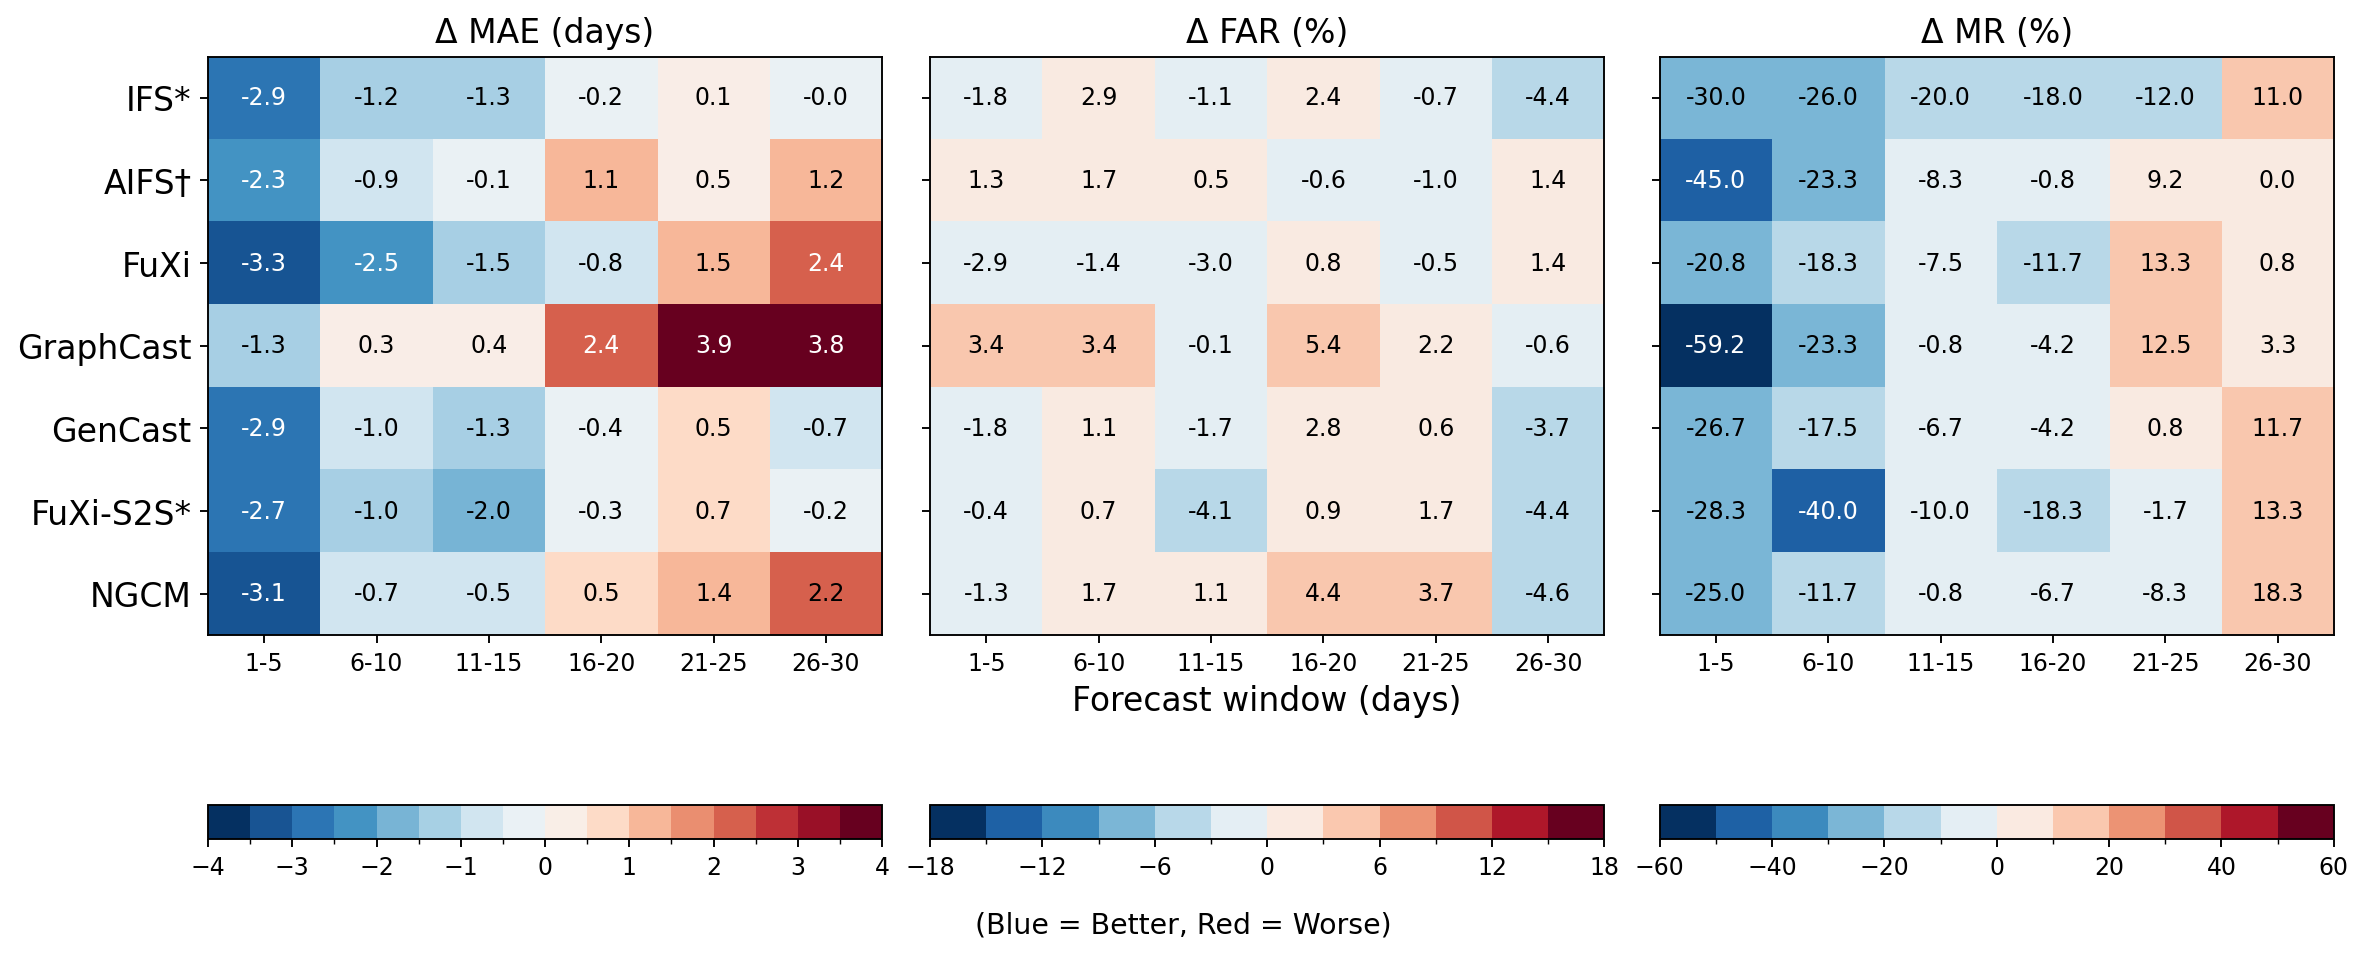


Done. Main outputs:
- c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\fig3_all_models_delta_long.csv
- c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\fig3_all_models_delta_heatmap.png
- c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\fig3_5day_forecastwindow_cmz_mae_cmz.csv
- c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\fig3_5day_forecastwindow_cmz_far_cmz.csv
- c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\fig3_5day_forecastwindow_cmz_mr_cmz.csv
- c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\examples\demo_notebooks\outputs\fig3_5day_forecastwindow_cmz_std_er.csv
- c:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\

In [10]:
# Step 8: Batch run for all models (paper-year aware) + MAT-like matrix export + figure


# Paper-year policy from author notes
paper_years_by_model = {
    "ifs": [2019, 2020, 2021, 2022, 2023],
    "aifs": [2019, 2020, 2021, 2022, 2023, 2024],
    "fuxi": [2019, 2020, 2021, 2022, 2023, 2024],
    "graphcast": [2019, 2020, 2021, 2022, 2023, 2024],
    "gencast": [2019, 2020, 2021, 2022, 2023, 2024],
    "fuxi-s2s": [2019, 2020, 2021],
    "ngcm": [2019, 2020, 2021, 2022, 2023, 2024],
}

# Model settings aligned with this repo's folder layout
all_model_configs = [
    {
        "model_name": "ifs",
        "model_type": "probabilistic",
        "model_forecast_dir": str(
            data_dir / "model_forecast_data" / "IFS-S2S" / "tp_4p0"
        ),
        "mem_num": 11,
        "date_filter_year": 2024,
    },
    {
        "model_name": "aifs",
        "model_type": "deterministic",
        "model_forecast_dir": str(
            data_dir / "model_forecast_data" / "aifs" / "daily_0z" / "tp_4p0"
        ),
        "mem_num": None,
        "date_filter_year": 2024,
    },
    {
        "model_name": "fuxi",
        "model_type": "deterministic",
        "model_forecast_dir": str(
            data_dir
            / "model_forecast_data"
            / "fuxi"
            / "output_daily_paper_0z_4p0"
            / "tp_lsm"
        ),
        "mem_num": None,
        "date_filter_year": 2024,
    },
    {
        "model_name": "graphcast",
        "model_type": "deterministic",
        "model_forecast_dir": str(
            data_dir
            / "model_forecast_data"
            / "graphcast37"
            / "output_twice_weekly_paper_0z_4p0"
            / "tp_lsm"
        ),
        "mem_num": None,
        "date_filter_year": 2024,
    },
    {
        "model_name": "gencast",
        "model_type": "probabilistic",
        "model_forecast_dir": str(
            data_dir / "model_forecast_data" / "gencast52" / "tp_lsm_4p0"
        ),
        "mem_num": 51,
        "date_filter_year": 2024,
    },
    {
        "model_name": "fuxi-s2s",
        "model_type": "probabilistic",
        "model_forecast_dir": str(
            data_dir / "model_forecast_data" / "fuxi_s2s" / "tp_4p0"
        ),
        "mem_num": 51,
        "date_filter_year": 2022,
    },
    {
        "model_name": "ngcm",
        "model_type": "probabilistic",
        "model_forecast_dir": str(
            data_dir / "model_forecast_data" / "ngcm51" / "climatology" / "tp_4p0"
        ),
        "mem_num": 51,
        "date_filter_year": 2024,
    },
]

mat_model_order = [
    "clim",
    "ifs",
    "aifs",
    "fuxi",
    "graphcast",
    "gencast",
    "fuxis2s",
    "ngcm51",
]
model_to_mat_name = {
    "ifs": "ifs",
    "aifs": "aifs",
    "fuxi": "fuxi",
    "graphcast": "graphcast",
    "gencast": "gencast",
    "fuxi-s2s": "fuxis2s",
    "ngcm": "ngcm51",
}

plot_model_order = ["ifs", "aifs", "fuxi", "graphcast", "gencast", "fuxi-s2s", "ngcm"]
plot_model_labels = {
    "ifs": "IFS*",
    "aifs": "AIFS\N{DAGGER}",
    "fuxi": "FuXi",
    "graphcast": "GraphCast",
    "gencast": "GenCast",
    "fuxi-s2s": "FuXi-S2S*",
    "ngcm": "NGCM",
}

metric_key_map = {
    "MAE (days)": "mae_cmz",
    "FAR (%)": "far_cmz",
    "MR (%)": "mr_cmz",
}

window_labels = [f"{s}-{e}" for s, e in WINDOW_BINS]
output_dir = Path(args["save_dir"])
output_dir.mkdir(parents=True, exist_ok=True)

# Storage for MAT-like matrices (rows: windows, cols: models)
matrices = {
    "mae_cmz": pd.DataFrame(np.nan, index=window_labels, columns=mat_model_order),
    "far_cmz": pd.DataFrame(np.nan, index=window_labels, columns=mat_model_order),
    "mr_cmz": pd.DataFrame(np.nan, index=window_labels, columns=mat_model_order),
    "std_er": pd.DataFrame(np.nan, index=window_labels, columns=mat_model_order),
}

# Storage for plotting deltas (rows: non-clim models, cols: windows)
delta_for_plot = {
    "MAE (days)": pd.DataFrame(np.nan, index=plot_model_order, columns=window_labels),
    "FAR (%)": pd.DataFrame(np.nan, index=plot_model_order, columns=window_labels),
    "MR (%)": pd.DataFrame(np.nan, index=plot_model_order, columns=window_labels),
}

all_delta_rows = []
baseline_conflicts = []

for mc in all_model_configs:
    model_name = mc["model_name"]
    years = paper_years_by_model[model_name]

    run_args = dict(args)
    run_args.update(
        {
            "model_name": model_name,
            "model_type": mc["model_type"],
            "model_forecast_dir": mc["model_forecast_dir"],
            "mem_num": mc["mem_num"],
            "years": years,
            "date_filter_year": mc["date_filter_year"],
            "mok": True,
        }
    )

    print(f"\nRunning model={model_name}, years={years}")
    df_m = compute_fig3_delta_table(run_args)

    # Save each model's detailed delta table
    per_model_csv = output_dir / f"fig3_delta_table_{model_name}.csv"
    df_m.to_csv(per_model_csv, index=False)
    print("Saved:", per_model_csv)

    # Fill MAT-like absolute matrices + delta plot tables
    mat_name = model_to_mat_name[model_name]
    for _, r in df_m.iterrows():
        metric = r["metric"]
        win = r["window"]
        key = metric_key_map[metric]

        model_val = float(r["model"]) if pd.notna(r["model"]) else np.nan
        clim_val = float(r["climatology"]) if pd.notna(r["climatology"]) else np.nan
        delta_val = float(r["delta"]) if pd.notna(r["delta"]) else np.nan

        # model absolute
        matrices[key].loc[win, mat_name] = model_val

        # shared climatology column (record conflict if different across model runs)
        prev_clim = matrices[key].loc[win, "clim"]
        if pd.isna(prev_clim):
            matrices[key].loc[win, "clim"] = clim_val
        elif pd.notna(clim_val) and (abs(prev_clim - clim_val) > 1e-8):
            baseline_conflicts.append((metric, win, model_name, prev_clim, clim_val))

        # for final 3-panel figure
        delta_for_plot[metric].loc[model_name, win] = delta_val

        all_delta_rows.append(
            {
                "model": model_name,
                "window": win,
                "metric": metric,
                "tolerance_days": int(r["tolerance_days"])
                if pd.notna(r["tolerance_days"])
                else np.nan,
                "model_value": model_val,
                "climatology_value": clim_val,
                "delta": delta_val,
                "years_used": ",".join(str(y) for y in years),
            }
        )

if baseline_conflicts:
    print(
        "\nWarning: climatology baseline differs across model runs for some metric/window entries."
    )
    print("Showing first 12 conflicts:")
    for c in baseline_conflicts[:12]:
        print(c)

# Save MAT-like CSV outputs
mat_prefix = output_dir / "fig3_5day_forecastwindow_cmz"
for key, df_key in matrices.items():
    out = Path(str(mat_prefix) + f"_{key}.csv")
    df_key.to_csv(out, index=True)
    print("Saved:", out)

model_str_csv = Path(str(mat_prefix) + "_model_str.csv")
pd.DataFrame({"model_str": mat_model_order}).to_csv(model_str_csv, index=False)
print("Saved:", model_str_csv)

all_delta_csv = output_dir / "fig3_all_models_delta_long.csv"
pd.DataFrame(all_delta_rows).to_csv(all_delta_csv, index=False)
print("Saved:", all_delta_csv)

# Draw 3-panel heatmap for all model deltas (legacy notebook style + discrete levels)
fig, axes = plt.subplots(1, 3, figsize=(13.8, 5.2), dpi=170, constrained_layout=True)
panel_specs = [
    ("MAE (days)", -4, 4, np.arange(-4, 4.5, 0.5), [-4, -3, -2, -1, 0, 1, 2, 3, 4]),
    ("FAR (%)", -18, 18, np.arange(-18, 19, 3), [-18, -12, -6, 0, 6, 12, 18]),
    ("MR (%)", -60, 60, np.arange(-60, 61, 10), [-60, -40, -20, 0, 20, 40, 60]),
]

for ax, (metric, vmin, vmax, boundaries, ticks) in zip(axes, panel_specs):
    arr = (
        delta_for_plot[metric].loc[plot_model_order, window_labels].values.astype(float)
    )
    norm = BoundaryNorm(boundaries=boundaries, ncolors=plt.cm.RdBu_r.N)
    im = ax.imshow(
        arr, cmap="RdBu_r", norm=norm, aspect="auto", interpolation="nearest"
    )

    ax.set_title(f"\N{GREEK CAPITAL LETTER DELTA} {metric}", fontsize=14)
    ax.set_xticks(np.arange(len(window_labels)))
    ax.set_xticklabels(window_labels, fontsize=10)
    ax.set_yticks(np.arange(len(plot_model_order)))
    if ax is axes[0]:
        ax.set_yticklabels(
            [plot_model_labels[m] for m in plot_model_order], fontsize=14
        )
    else:
        ax.set_yticklabels([])

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            if np.isnan(val):
                txt = "nan"
                color = "black"
            else:
                txt = f"{val:.1f}"
                color = (
                    "white" if abs(val) > 0.55 * max(abs(vmin), abs(vmax)) else "black"
                )
            ax.text(j, i, txt, ha="center", va="center", fontsize=10, color=color)

    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.14,
        fraction=0.07,
        boundaries=boundaries,
    )
    cbar.set_ticks(ticks)

axes[1].set_xlabel("Forecast window (days)", fontsize=14)
fig.text(0.5, -0.02, "(Blue = Better, Red = Worse)", ha="center", va="top", fontsize=12)

fig_path = output_dir / "fig3_all_models_delta_heatmap.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
print("Saved:", fig_path)

plt.show()

print("\nDone. Main outputs:")
print("-", all_delta_csv)
print("-", fig_path)
print("-", Path(str(mat_prefix) + "_mae_cmz.csv"))
print("-", Path(str(mat_prefix) + "_far_cmz.csv"))
print("-", Path(str(mat_prefix) + "_mr_cmz.csv"))
print("-", Path(str(mat_prefix) + "_std_er.csv"))
print("-", model_str_csv)